In [1]:
%load_ext autoreload
%autoreload 2
# %pip install pillow git+https://github.com/graphcore-research/pytorch-tensor-tracker
# %pip install torchvision --index-url https://download.pytorch.org/whl/cpu

import matplotlib.pyplot as plt
import PIL.Image
import re
import tensor_tracker
import torch
from torch import Tensor
import torch.nn.functional as F
import transformers
import urllib.request
import numpy as np
import math

transformers.utils.logging.disable_progress_bar()

# Investigation

In [2]:
model = transformers.MllamaForConditionalGeneration.from_pretrained(
    "meta-llama/Llama-3.2-11B-Vision",
    torch_dtype="float32",
)
processor = transformers.AutoProcessor.from_pretrained(model.config._name_or_path)

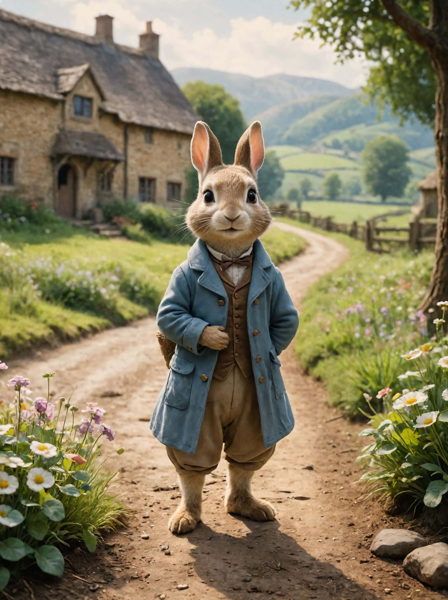

In [44]:
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg"
image = PIL.Image.open(urllib.request.urlopen(image_url))
image = image.resize([448, 600]); display(image)
prompt = "<|image|><|begin_of_text|>If I had to write a haiku for this one"
inputs_hf = processor(image, prompt, return_tensors="pt")

In [ ]:
%%time
print(processor.decode(model.generate(**inputs_hf, max_new_tokens=30)[0]))

vision_config is None, using default mllama vision config
text_config is None, using default mllama text config


<|begin_of_text|><|image|><|begin_of_text|>If I had to write a haiku for this one, it would be:.\nPeter Rabbit's adventures.\nIn Beatrix Potter's charming tales.\nA timeless delight.\nPeter Rabbit's
CPU times: user 4min 55s, sys: 6.84 s, total: 5min 2s
Wall time: 1min 4s


### Parameters

In [5]:
skipping = False
visited = set([])
for name, p in model.named_parameters():
    layer_n = re.search(r"(\d)+", name)
    if (not layer_n) or int(layer_n.group(0)) == 0:
        print(f"{name:>80} {tuple(p.shape)}")
        skipping = False
    elif not skipping:
        print("...")
        skipping = True

                                                    vision_model.class_embedding (1280,)
                                             vision_model.patch_embedding.weight (1280, 3, 14, 14)
                                    vision_model.gated_positional_embedding.gate (1,)
                               vision_model.gated_positional_embedding.embedding (1025, 1280)
                   vision_model.gated_positional_embedding.tile_embedding.weight (9, 5248000)
                                 vision_model.pre_tile_positional_embedding.gate (1,)
                     vision_model.pre_tile_positional_embedding.embedding.weight (9, 5120)
                                vision_model.post_tile_positional_embedding.gate (1,)
                    vision_model.post_tile_positional_embedding.embedding.weight (9, 5120)
                                               vision_model.layernorm_pre.weight (1280,)
                                                 vision_model.layernorm_pre.bias (1280,)
      

### Inputs


We ignore the batch dimension.

Params:

| Param | Value |
| --- | --- |
| `max_sequence_length` | 131,072 |
| `vocab_size` | 128,256 |
| `image_size` | 448 |
| `max_n_tiles` | 4 |
| `img_mean` | `[0.48145466, 0.4578275, 0.40821073]` |
| `img_std` | `[0.26862954, 0.26130258, 0.27577711]` |

Shapes:

 - `input_ids` of shape `(sequence_length)` in `[0, vocab_size)`
   - Format: `['<|begin_of_text|>', '<|image|>', '<|begin_of_text|>', ...]`
 - `attention_mask` of shape `(sequence_length)`
   - `1` for unmasked tokens
 - `cross_attention_mask` of shape `(sequence_length, n_images, n_tiles)`
   - `1` for unmasked token-tile
   - `0` for the first token `<|begin_of_text|>`
   - `0` for absent tiles
 - `pixel_values` of shape `(n_images, n_tiles, 3, image_size, image_size)`
   - Tiles in scan order e.g. `[top-left, top-right, bottom-left, bottom-right]`
   - Colour channels `[R, G, B]`
   - Pixels in scan order `img[-y, x]`
   - Right & bottom -padded with `0`
   - Small images are stretched so that their larger dimension fills `image_size` & the other is padded
   - Large images are squashed to that their larger dimension fills `2 * image_size` & the other is padded
   - Normalised image: `((raw_data / 255) - img_mean) / img_std` (mean and std from [preprocessor_config.json](https://huggingface.co/meta-llama/Llama-3.2-11B-Vision/blob/main/preprocessor_config.json))
 - `aspect_ratio_id` of shape `(n_images)`
   - Index into `config.vision_config.supported_aspect_ratios` e.g. `6 => [2, 2]` (2 tiles by 2 tiles), and `0 => [1, 1]`
 - `aspect_ratio_mask` of shape `(n_images, n_tiles)`
   - `1` for unmasked tiles

{'input_ids': (torch.int64, torch.Size([1, 14])),
 'attention_mask': (torch.int64, torch.Size([1, 14])),
 'pixel_values': (torch.float32, torch.Size([1, 1, 4, 3, 448, 448])),
 'aspect_ratio_ids': (torch.int64, torch.Size([1, 1])),
 'aspect_ratio_mask': (torch.int64, torch.Size([1, 1, 4])),
 'cross_attention_mask': (torch.int64, torch.Size([1, 14, 1, 4]))}

# Tokens:
['<|begin_of_text|>', '<|image|>', '<|begin_of_text|>', 'If', 'ĠI', 'Ġhad', 'Ġto', 'Ġwrite', 'Ġa', 'Ġha', 'iku', 'Ġfor', 'Ġthis', 'Ġone']
# Attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
# Cross attention mask:
tensor([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
# Aspect ratio id: 5
# Aspect ratio mask: tensor([1, 1, 0, 0])


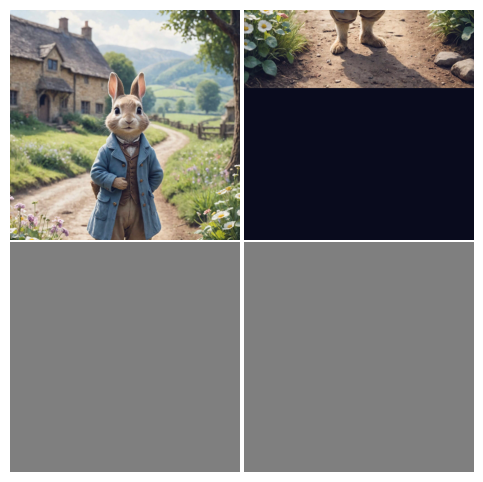

In [47]:
display({k: (v.dtype, v.shape) for k, v in inputs_hf.items()})
print("# Tokens:")
print(processor.tokenizer.convert_ids_to_tokens(inputs_hf.input_ids[0]))
print("# Attention mask:")
print(inputs_hf.attention_mask.squeeze())
print("# Cross attention mask:")
print(inputs_hf.cross_attention_mask.squeeze().T)
print("# Aspect ratio id:", inputs_hf.aspect_ratio_ids.item())
print("# Aspect ratio mask:", inputs_hf.aspect_ratio_mask.squeeze())

_, axs = plt.subplots(2, 2, figsize=(6, 6))
img = inputs_hf.pixel_values.clone()
for (chunk, ax) in zip(img.squeeze(), axs.flatten()):
    ax.imshow((chunk.movedim(0, -1) / img.abs().max() + 1) / 2)
    ax.set_axis_off()
plt.subplots_adjust(wspace=0.01, hspace=0.01)

### Activations

In [ ]:
with torch.no_grad(), tensor_tracker.track(model, stash_value=lambda t: tuple(t.shape)) as tracker:
    out = model(**inputs_hf)
    print(processor.tokenizer.convert_ids_to_tokens(out.logits[0, -1:].argmax(-1)))
skipping = False
for s in tracker:
    layer_n = re.search(r"(\d)+", s.name)
    if (not layer_n) or int(layer_n.group(0)) == 0:
        print(f"{s.name:>80} {s.value}")
        skipping = False
    elif not skipping:
        print("...")
        skipping = True

[',']
                                                    vision_model.patch_embedding (4, 1280, 32, 32)
                            vision_model.pre_tile_positional_embedding.embedding (1, 1, 5120)
                                      vision_model.pre_tile_positional_embedding (1, 4, 1024, 1280)
                          vision_model.gated_positional_embedding.tile_embedding (1, 1, 5248000)
                                         vision_model.gated_positional_embedding (1, 4, 1025, 1280)
                                                      vision_model.layernorm_pre (1, 4, 1025, 1280)
                               vision_model.transformer.layers.0.input_layernorm (1, 4128, 1280)
                              vision_model.transformer.layers.0.self_attn.q_proj (1, 4128, 1280)
                              vision_model.transformer.layers.0.self_attn.k_proj (1, 4128, 1280)
                              vision_model.transformer.layers.0.self_attn.v_proj (1, 4128, 1280)
                

# Implementation

In [78]:
# reference
with torch.no_grad(), tensor_tracker.track(model, include="^vision_model.layernorm_pre$") as tracker:
    out = model(**inputs_hf)
    print(processor.tokenizer.convert_ids_to_tokens(out.logits[0, -1:].argmax(-1)))
print(tracker[0].value.shape)

[',']
torch.Size([1, 4, 1025, 1280])


In [74]:
import mllama as M

config = M.config_from_huggingface(model.config, processor.image_processor)
params = M.params_from_huggingface(config, model)
inputs = M.get_inputs(config, torch.tensor(np.array(image)))

In [81]:
patches = F.conv2d(
    inputs.image, params.patch_embedding, stride=config.patch_size,
).flatten(start_dim=-2).transpose(-1, -2)
patches += params.vision_positional_embedding[inputs.aspect_ratio_id, :patches.shape[0]]
patches = torch.cat([params.vision_class_embedding[inputs.aspect_ratio_id, :patches.shape[0]].unsqueeze(-2), patches], dim=-2)
patches = M.layer_norm(patches, params.vision_pre_norm)

print(patches.shape)
torch.testing.assert_close(patches, tracker[0].value.squeeze(0)[:patches.shape[0]])

torch.Size([2, 1025, 1280])
